In [ ]:
# --- Imports ---
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.utils.class_weight import compute_class_weight

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [ ]:
# --- Upload in Colab ---
from google.colab import files
uploaded = files.upload()

print("Uploaded:", list(uploaded.keys()))

Uploaded: []


In [ ]:
# --- Paths ---
DATA_FILE = "water-treatment.data"
NAMES_FILE = "water_treatment.names"

# --- Load raw data ---
# UCI file is typically comma-separated, with '?' marking missing
raw = pd.read_csv(
    DATA_FILE,
    header=None,
    sep=",",
    na_values=["?", " ?"],
    engine="python"
)

print("Raw shape:", raw.shape)
raw.head()

Raw shape: (527, 39)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38
0,D-1/3/90,44101.0,1.5,7.8,NaN,407.0,166.0,66.3,4.5,2110,7.9,NaN,228,70.2,5.5,2120,7.9,NaN,280.0,94.0,72.3,0.3,2010,7.3,NaN,84.0,21.0,81.0,0.02,2000.0,NaN,58.8,95.5,NaN,70.0,NaN,79.4,87.3,99.6
1,D-2/3/90,39024.0,3.0,7.7,NaN,443.0,214.0,69.2,6.5,2660,7.7,NaN,244,75.4,7.7,2570,7.6,NaN,474.0,96.0,79.2,0.4,2700,7.5,NaN,91.0,17.0,94.1,0.00,2590.0,NaN,60.7,94.8,NaN,80.8,NaN,79.5,92.1,100.0
2,D-4/3/90,32229.0,5.0,7.6,NaN,528.0,186.0,69.9,3.4,1666,7.7,NaN,220,72.7,4.5,1594,7.7,NaN,272.0,92.0,78.3,0.2,1742,7.6,NaN,128.0,21.0,81.0,0.05,1888.0,NaN,58.2,95.6,NaN,52.9,NaN,75.8,88.7,98.5
3,D-5/3/90,35023.0,3.5,7.9,205.0,588.0,192.0,65.6,4.5,2430,7.8,236.0,268,73.1,8.5,2280,7.8,158.0,376.0,96.0,77.1,0.4,2060,7.6,20.0,104.0,20.0,96.7,0.00,1840.0,33.1,64.2,95.3,87.3,72.3,90.2,82.3,89.6,100.0
4,D-6/3/90,36924.0,1.5,8.0,242.0,496.0,176.0,64.8,4.0,2110,7.9,NaN,236,57.6,4.5,2020,7.8,NaN,372.0,88.0,68.2,0.2,2250,7.6,19.0,108.0,22.0,65.9,0.02,2120.0,NaN,62.7,95.6,NaN,71.0,92.1,78.2,87.5,99.5


In [ ]:
# --- Convert all columns to numeric (coerce errors to NaN) ---
df = raw.apply(pd.to_numeric, errors="coerce")

print("After numeric conversion:", df.shape)
print("Missing ratio (%):", (df.isna().mean().mean() * 100).round(2))
df.head()

After numeric conversion: (527, 39)
Missing ratio (%): 5.44


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38
0,NaN,44101.0,1.5,7.8,NaN,407.0,166.0,66.3,4.5,2110,7.9,NaN,228,70.2,5.5,2120,7.9,NaN,280.0,94.0,72.3,0.3,2010,7.3,NaN,84.0,21.0,81.0,0.02,2000.0,NaN,58.8,95.5,NaN,70.0,NaN,79.4,87.3,99.6
1,NaN,39024.0,3.0,7.7,NaN,443.0,214.0,69.2,6.5,2660,7.7,NaN,244,75.4,7.7,2570,7.6,NaN,474.0,96.0,79.2,0.4,2700,7.5,NaN,91.0,17.0,94.1,0.00,2590.0,NaN,60.7,94.8,NaN,80.8,NaN,79.5,92.1,100.0
2,NaN,32229.0,5.0,7.6,NaN,528.0,186.0,69.9,3.4,1666,7.7,NaN,220,72.7,4.5,1594,7.7,NaN,272.0,92.0,78.3,0.2,1742,7.6,NaN,128.0,21.0,81.0,0.05,1888.0,NaN,58.2,95.6,NaN,52.9,NaN,75.8,88.7,98.5
3,NaN,35023.0,3.5,7.9,205.0,588.0,192.0,65.6,4.5,2430,7.8,236.0,268,73.1,8.5,2280,7.8,158.0,376.0,96.0,77.1,0.4,2060,7.6,20.0,104.0,20.0,96.7,0.00,1840.0,33.1,64.2,95.3,87.3,72.3,90.2,82.3,89.6,100.0
4,NaN,36924.0,1.5,8.0,242.0,496.0,176.0,64.8,4.0,2110,7.9,NaN,236,57.6,4.5,2020,7.8,NaN,372.0,88.0,68.2,0.2,2250,7.6,19.0,108.0,22.0,65.9,0.02,2120.0,NaN,62.7,95.6,NaN,71.0,92.1,78.2,87.5,99.5


In [ ]:
# --- Chronological split ---
T = len(df)
i_train = int(0.60 * T)
i_val   = int(0.80 * T)

df_train = df.iloc[:i_train].copy()
df_val   = df.iloc[i_train:i_val].copy()
df_test  = df.iloc[i_val:].copy()

(df_train.shape, df_val.shape, df_test.shape)

((316, 39), (105, 39), (106, 39))

In [ ]:
# --- Train-only imputation and scaling ---
mu = df_train.mean()
sd = df_train.std().replace(0, 1.0)

def transform_frame(F):
    F2 = F.copy()
    F2 = F2.fillna(mu)
    return (F2 - mu) / sd

Z_train = transform_frame(df_train)
Z_val   = transform_frame(df_val)
Z_test  = transform_frame(df_test)

Z_all = pd.concat([Z_train, Z_val, Z_test], axis=0)
Z_all.shape

(527, 39)

In [ ]:
# --- Event definition: abrupt multivariate transition ---
# We define a transition score as the L2 norm of day-to-day differences in standardized space.

def transition_score(Z):
    dZ = Z.diff().fillna(0.0)
    score = np.sqrt((dZ**2).sum(axis=1))
    return score

score_all = transition_score(Z_all)

# Fit threshold on TRAIN only
PERCENTILE = 95  # you can later test 90/95/97 as sensitivity
thr = np.nanpercentile(score_all.iloc[:i_train].values, PERCENTILE)

event_days = (score_all >= thr)

print("Percentile:", PERCENTILE)
print("Threshold:", float(thr))
print("Event days total:", int(event_days.sum()))

Percentile: 95
Threshold: 11.30586104266221
Event days total: 31


In [ ]:
# --- Event run statistics (to rule out persistence artifacts) ---
def event_run_statistics(event_bool):
    e = event_bool.astype(bool).values
    n_event_days = int(e.sum())

    durations = []
    cur = 0
    for v in e:
        if v:
            cur += 1
        else:
            if cur > 0:
                durations.append(cur)
                cur = 0
    if cur > 0:
        durations.append(cur)

    n_events = len(durations)
    stats = {
        "n_event_days": n_event_days,
        "n_events": n_events,
        "durations": durations,
        "duration_mean": float(np.mean(durations)) if n_events else np.nan,
        "duration_median": float(np.median(durations)) if n_events else np.nan,
        "duration_max": int(np.max(durations)) if n_events else 0
    }
    return stats

stats = event_run_statistics(event_days)
stats

{'n_event_days': 31,
 'n_events': 20,
 'durations': [4, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 2, 1, 2, 1, 1],
 'duration_mean': 1.55,
 'duration_median': 1.0,
 'duration_max': 4}

In [ ]:
# --- Horizon labels: y_t=1 if any event occurs in [t+1, t+H] ---
def make_horizon_labels(event_bool, H=3):
    e = event_bool.astype(int).values
    y = np.zeros_like(e)
    for i in range(len(e)):
        j1 = i + 1
        j2 = min(i + H, len(e) - 1)
        if j1 <= j2 and e[j1:j2+1].sum() > 0:
            y[i] = 1
    return pd.Series(y, index=event_bool.index, name=f"y_H{H}")

H = 3
y = make_horizon_labels(event_days, H=H)

print("y positives:", int(y.sum()), "out of", len(y))
y.value_counts()

y positives: 69 out of 527


,count
y_H3,
0,458
1,69


In [ ]:
# --- Feature engineering from standardized daily data ---
# For each day t, use a window of W days ending at t and compute simple stats per variable.

W = 14

def build_window_features(Z, W=14):
    # Z: DataFrame [T x C], standardized
    feats = []
    idx = []
    for t in range(W-1, len(Z)):
        win = Z.iloc[t-W+1:t+1]  # [W x C]
        x_last = win.iloc[-1].values
        x_mean = win.mean(axis=0).values
        x_std  = win.std(axis=0).values

        # trend slope via simple linear regression over time index 0..W-1
        tt = np.arange(W)
        tt_mean = tt.mean()
        denom = ((tt - tt_mean)**2).sum()
        # slope per variable: cov(t, x)/var(t)
        x_vals = win.values
        cov = ((tt - tt_mean)[:, None] * (x_vals - x_vals.mean(axis=0)[None, :])).sum(axis=0)
        slope = cov / (denom + 1e-12)

        # last difference
        if W >= 2:
            delta = win.iloc[-1].values - win.iloc[-2].values
        else:
            delta = np.zeros(win.shape[1])

        f = np.concatenate([x_last, x_mean, x_std, slope, delta])
        feats.append(f)
        idx.append(Z.index[t])

    F = pd.DataFrame(np.vstack(feats), index=idx)
    return F

F_all = build_window_features(Z_all, W=W)
y_aligned = y.loc[F_all.index]
event_days_aligned = event_days.loc[F_all.index]

print("Feature matrix:", F_all.shape)
print("Aligned y positives:", int(y_aligned.sum()))

Feature matrix: (514, 195)
Aligned y positives: 63


In [ ]:
# --- Rolling-origin splits ---
def make_rolling_splits(n_days, train_frac=0.60, val_frac=0.20, n_splits=4):
    train_len = int(train_frac * n_days)
    val_len   = int(val_frac * n_days)
    test_len  = n_days - train_len - val_len

    # Move forward by a fraction of test window
    step = max(1, test_len // n_splits)

    splits = []
    for s in range(n_splits):
        train_end = train_len + s * step
        val_end   = min(train_end + val_len, n_days - 1)
        test_end  = min(val_end + test_len, n_days)
        if test_end <= val_end or val_end <= train_end:
            continue
        splits.append((train_end, val_end, test_end))
    return splits

splits = make_rolling_splits(len(F_all), train_frac=0.60, val_frac=0.20, n_splits=4)
splits

[(308, 410, 514), (334, 436, 514), (360, 462, 514), (386, 488, 514)]

In [ ]:
# --- XGBoost baseline ---
try:
    import xgboost as xgb
    print("xgboost version:", xgb.__version__)
except Exception as e:
    print("xgboost not available, installing...")
    !pip -q install xgboost
    import xgboost as xgb
    print("xgboost version:", xgb.__version__)

xgboost version: 3.1.2


In [ ]:
# --- Operational metrics ---
def false_alarms_per_30d(alert_bool):
    days = len(alert_bool)
    if days == 0:
        return 0.0
    fa = int(alert_bool.sum())
    return fa * (30.0 / days)

def hit_rate_on_event_days(event_days_bool, alert_bool):
    # event_days_bool: True on days considered as "event days"
    events = event_days_bool.astype(bool)
    n_event_days = int(events.sum())
    if n_event_days == 0:
        return np.nan
    hits = int((events & alert_bool).sum())
    return hits / n_event_days

def operational_curve(scores, event_days_bool, grid_fa=np.linspace(0, 25, 51)):
    # Sweep thresholds by quantiles of scores
    qs = np.linspace(0.0, 1.0, 200)
    ths = np.quantile(scores.dropna().values, qs)

    points = []
    for th in ths:
        alert = (scores >= th)
        fa30 = false_alarms_per_30d(alert)
        hr = hit_rate_on_event_days(event_days_bool, alert)
        points.append((fa30, hr))

    pts = pd.DataFrame(points, columns=["fa30", "hit_rate"]).sort_values("fa30")
    # collapse duplicates
    pts = pts.groupby("fa30", as_index=False)["hit_rate"].mean()

    fa_vals = pts["fa30"].values
    hr_vals = pts["hit_rate"].values
    hr_interp = np.interp(grid_fa, fa_vals, hr_vals, left=hr_vals[0], right=hr_vals[-1])
    return grid_fa, hr_interp, pts

def extract_points(grid_fa, hr_mean, targets=(1,5,10,20)):
    rows = []
    for t in targets:
        i = int(np.argmin(np.abs(grid_fa - t)))
        rows.append((float(grid_fa[i]), float(hr_mean[i])))
    return pd.DataFrame(rows, columns=["fa_per_30d", "hit_rate_mean"])

Splits used: 4 out of 4
ROC-AUC mean (where defined): 0.648936170212766
AP mean (where defined): 0.16191910418013358


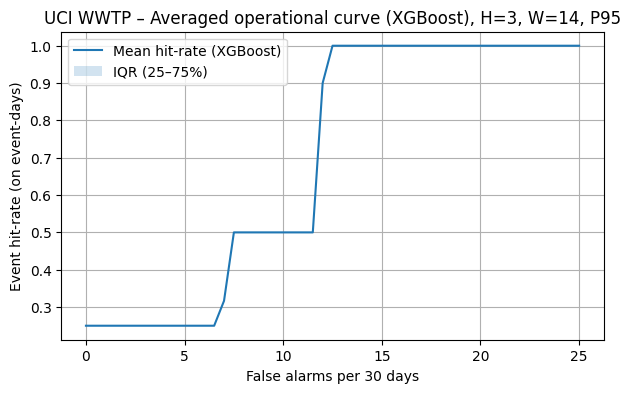

In [ ]:
# --- Train XGBoost per split and average operational curves ---
grid_fa = np.linspace(0, 25, 51)

curves = []
roc_list = []
ap_list = []

for (train_end, val_end, test_end) in splits:
    X_tr = F_all.iloc[:train_end].values
    y_tr = y_aligned.iloc[:train_end].values

    X_te = F_all.iloc[val_end:test_end].values
    y_te = y_aligned.iloc[val_end:test_end].values

    # Scale_pos_weight for imbalance
    n_pos = max(1, int(y_tr.sum()))
    n_neg = max(1, int((y_tr == 0).sum()))
    spw = n_neg / n_pos

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=spw,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    model.fit(X_tr, y_tr)

    s_te = model.predict_proba(X_te)[:, 1]
    s_te = pd.Series(s_te, index=F_all.iloc[val_end:test_end].index)

    # Sample-level metrics (context only)
    if len(np.unique(y_te)) == 2:
        roc_list.append(roc_auc_score(y_te, s_te.values))
        ap_list.append(average_precision_score(y_te, s_te.values))

    ev_te = event_days_aligned.iloc[val_end:test_end]

    fa_grid, hr_grid, _ = operational_curve(s_te, ev_te, grid_fa=grid_fa)
    curves.append(hr_grid)

C = np.vstack(curves)
hr_mean = np.nanmean(C, axis=0)
hr_p25  = np.nanpercentile(C, 25, axis=0)
hr_p75  = np.nanpercentile(C, 75, axis=0)

print("Splits used:", len(curves), "out of", len(splits))
print("ROC-AUC mean (where defined):", float(np.mean(roc_list)) if roc_list else np.nan)
print("AP mean (where defined):", float(np.mean(ap_list)) if ap_list else np.nan)

plt.figure(figsize=(7,4))
plt.plot(grid_fa, hr_mean, label="Mean hit-rate (XGBoost)")
plt.fill_between(grid_fa, hr_p25, hr_p75, alpha=0.2, label="IQR (25–75%)")
plt.xlabel("False alarms per 30 days")
plt.ylabel("Event hit-rate (on event-days)")
plt.title(f"UCI WWTP – Averaged operational curve (XGBoost), H={H}, W={W}, P{PERCENTILE}")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
op_points = extract_points(grid_fa, hr_mean, targets=(1,5,10,20))
op_points

,fa_per_30d,hit_rate_mean
0,1.0,0.25
1,5.0,0.25
2,10.0,0.50
3,20.0,1.00


'hit-rate_vs_FA30d_XGBoost_UCI.png'

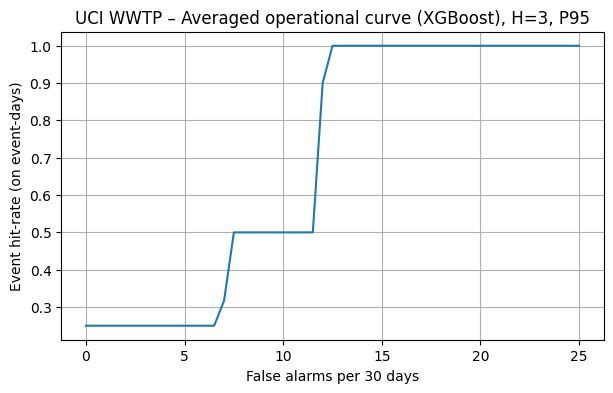

In [ ]:
out_png = "hit-rate_vs_FA30d_XGBoost_UCI.png"

plt.figure(figsize=(7,4))
plt.plot(grid_fa, hr_mean)
plt.fill_between(grid_fa, hr_p25, hr_p75, alpha=0.2)
plt.xlabel("False alarms per 30 days")
plt.ylabel("Event hit-rate (on event-days)")
plt.title(f"UCI WWTP – Averaged operational curve (XGBoost), H={H}, P{PERCENTILE}")
plt.grid(True)
plt.savefig(out_png, dpi=200, bbox_inches="tight")
out_png

In [ ]:
# --- Print LaTeX-ready table rows ---
for _, r in op_points.iterrows():
    print(f"{r['fa_per_30d']:.0f} & {r['hit_rate_mean']:.3f} \\\\")

1 & 0.250 \\
5 & 0.250 \\
10 & 0.500 \\
20 & 1.000 \\
